# Imports

In [2]:
# ==============================
# Warnings
# ==============================
import warnings
warnings.filterwarnings('ignore')

# ==============================
# Core Libraries
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ==============================
# Preprocessing & ML Utilities
# ==============================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# ==============================
# Classical Machine Learning Models
# ==============================
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

# ==============================
# Gradient Boosting
# ==============================
from xgboost import XGBClassifier, XGBRegressor

# ==============================
# Text Feature Engineering
# ==============================
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
import gensim.downloader as api
from gensim.models import Word2Vec

# ==============================
# Deep Learning (TensorFlow / Keras)
# ==============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==============================
# Transformer Models (HuggingFace / PyTorch)
# ==============================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from chronos import ChronosPipeline

from transformers import (
    AutoTokenizer,
    AutoModel,
    DistilBertTokenizer,
    DistilBertModel
)

# ==============================
# Evaluation Metrics
# ==============================
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    f1_score,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==============================
# Data Profiling
# ==============================
from ydata_profiling import ProfileReport

# ==============================
# Statistical Analysis
# ==============================
from scipy.stats import pearsonr

# ==============================
# Utilities
# ==============================
from tqdm import tqdm
from IPython.display import display

# Load Data

In [4]:
# Load dataset
df = pd.read_csv("master_retail_dataset_v2.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# View sample data
df.head()

Shape: (2000, 58)

Columns:
 ['Date', 'DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Is_Holiday', 'Product_ID', 'Category', 'Base_Price', 'Discount_Percentage', 'Current_Price', 'Store_ID', 'Store_Type', 'Competitor_Price', 'Footfall_Index', 'Avg_Temperature', 'Rainfall_mm', 'Social_Media_Sentiment', 'Lead_Time_Days', 'Safety_Stock_Level', 'Stock_On_Hand', 'Daily_Units_Sold', 'Festival_Name', 'Festival_Type', 'UPC_EAN', 'Product_Name', 'Sub_Category', 'Brand_Name', 'Brand_Tier', 'Shelf_Life_Days', 'No_of_Checkout_Counters', 'Avg_Billing_Time_min', 'Local_Population_Density', 'Product_Age_Days', 'No_of_Customer_Purchases', 'Unit_Cost', 'Promotional_Campaign_Flag', 'Competitor_Promotion_Flag', 'Google_Trends_Current_Wk', 'Google_Trends_Lag_1w', 'Shelf_Capacity', 'Promotion_Type', 'Marketing_Spend', 'Payday_Flag', 'School_Vacation_Flag', 'Local_Event_Flag', 'Launch_Date', 'Seasonal_Product_Flag', 'Online_Sales_Units', 'In_Store_Sales_Units', 'App_Traffic_Index', 'Website_Visits', 'Backorder

,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,...,Online_Sales_Units,In_Store_Sales_Units,App_Traffic_Index,Website_Visits,Backorder_Flag,Supplier_Delay_Days,Fill_Rate_Pct,Loyalty_Program_Usage_Count,Repeat_Purchase_Rate,Avg_Basket_Size
0,04/13/2023,3,4,2023,0,0,1002,Grocery,410.09,0.01,...,12,71,488,896,N,0,88.93,11,0.14,3.77
1,12/15/2023,4,12,2023,0,0,1014,Home,89.98,0.30,...,31,71,619,1406,N,2,90.16,31,0.14,1.48
2,09/28/2023,3,9,2023,0,0,1015,Electronics,404.88,0.14,...,32,57,626,1432,N,6,88.00,23,0.38,1.07
3,04/17/2023,0,4,2023,0,0,1012,Grocery,347.97,0.43,...,32,66,626,1432,N,2,91.17,7,0.13,4.67
4,03/13/2023,0,3,2023,0,0,1016,Grocery,280.16,0.14,...,23,77,564,1191,N,0,89.39,9,0.16,2.17


# Data Profiler

In [6]:
profile = ProfileReport(df, explorative=True)

profile.to_file("DataProfiler.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|          | 0/58 [00:00<?, ?it/s]
%|▏         | 1/58 [00:00<00:29,  1.90it/s]
%|▎         | 2/58 [00:00<00:17,  3.13it/s]
%|███▉      | 23/58 [00:01<00:01, 30.44it/s]
100%|██████████| 58/58 [00:01<00:00, 45.46it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Data Cleaning

In [8]:
df_clean = df.copy()

# -------------------------------
# 1. Convert date-like columns + extract features
# -------------------------------
for col in df_clean.columns:
    if "date" in col.lower():
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        df_clean[col + "_day"] = df_clean[col].dt.day
        df_clean[col + "_month"] = df_clean[col].dt.month

# -------------------------------
# 2. Handle missing values
# -------------------------------
for col in df_clean.columns:
    if df_clean[col].dtype in ['int64', 'float64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        if not df_clean[col].mode().empty:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        else:
            df_clean[col] = df_clean[col].fillna("missing")

# -------------------------------
# 3. Convert Y/N → 1/0
# -------------------------------
for col in df_clean.select_dtypes(include='object').columns:
    unique_vals = df_clean[col].dropna().unique()
    
    if set(unique_vals).issubset({'Y', 'N'}):
        df_clean[col] = df_clean[col].map({'Y': 1, 'N': 0})

# -------------------------------
# 4. Drop high-cardinality numeric columns
# -------------------------------
for col in df_clean.columns:
    if df_clean[col].dtype in ['int64', 'float64']:
        if df_clean[col].nunique() / len(df_clean) > 0.95:
            df_clean.drop(columns=[col], inplace=True)

# -------------------------------
# 5. Check result
# -------------------------------
print("After Cleaning Shape:", df_clean.shape)
print("\nRemaining Object Columns:\n", df_clean.select_dtypes(include='object').columns.tolist())

After Cleaning Shape: (2000, 58)

Remaining Object Columns:
 ['Category', 'Store_Type', 'Festival_Name', 'Festival_Type', 'Product_Name', 'Sub_Category', 'Brand_Name', 'Brand_Tier', 'Promotion_Type']


# Feature split

In [10]:
# -------------------------------
# Step 3: Feature / Target Split (Dynamic)
# -------------------------------

target_col = 'Daily_Units_Sold'

if target_col not in df_clean.columns:
    raise ValueError(f"Target column {target_col} not found in dataset")

# Features
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Detect numerical and categorical columns dynamically
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Detect text columns dynamically (avg string length > 15)
text_cols = [col for col in cat_cols if X[col].astype(str).apply(len).mean() > 15]

# Remaining categorical columns (excluding text columns)
cat_cols_final = [col for col in cat_cols if col not in text_cols]

# Output for verification
print("Target Column:", target_col)
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols_final)
print("Text Columns:", text_cols)

Target Column: Daily_Units_Sold
Numerical Columns: ['DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Is_Holiday', 'Product_ID', 'Discount_Percentage', 'Store_ID', 'Footfall_Index', 'Avg_Temperature', 'Rainfall_mm', 'Social_Media_Sentiment', 'Lead_Time_Days', 'Safety_Stock_Level', 'Stock_On_Hand', 'UPC_EAN', 'Shelf_Life_Days', 'No_of_Checkout_Counters', 'Avg_Billing_Time_min', 'Local_Population_Density', 'Product_Age_Days', 'No_of_Customer_Purchases', 'Promotional_Campaign_Flag', 'Competitor_Promotion_Flag', 'Google_Trends_Current_Wk', 'Google_Trends_Lag_1w', 'Shelf_Capacity', 'Marketing_Spend', 'Payday_Flag', 'School_Vacation_Flag', 'Local_Event_Flag', 'Seasonal_Product_Flag', 'Online_Sales_Units', 'In_Store_Sales_Units', 'App_Traffic_Index', 'Website_Visits', 'Backorder_Flag', 'Supplier_Delay_Days', 'Fill_Rate_Pct', 'Loyalty_Program_Usage_Count', 'Repeat_Purchase_Rate', 'Avg_Basket_Size', 'Date_day', 'Date_month', 'Launch_Date_day', 'Launch_Date_month']
Categorical Columns: ['Category', '

# Data Preprocessing

In [12]:
# -------------------------------
# Step 4: Dynamic Preprocessing (No Encoding)
# -------------------------------

# Identify ID-like columns dynamically (high cardinality)
id_threshold = 0.8  # >80% unique = likely ID
n_rows = X.shape[0]
id_cols = [col for col in num_cols if X[col].nunique() / n_rows > id_threshold]

# Drop ID columns
X_proc = X.drop(columns=id_cols)

# Update numeric columns list
num_cols_proc = [col for col in num_cols if col not in id_cols]
cat_cols_proc = cat_cols_final
text_cols_proc = text_cols

# Fill missing values
for col in num_cols_proc:
    X_proc[col] = X_proc[col].fillna(X_proc[col].median())

for col in cat_cols_proc:
    X_proc[col] = X_proc[col].fillna('missing')

for col in text_cols_proc:
    X_proc[col] = X_proc[col].fillna('')

# Scale numeric columns
scaler = StandardScaler()
if num_cols_proc:
    X_proc[num_cols_proc] = scaler.fit_transform(X_proc[num_cols_proc])

print("Processed Shape (ready for vectorization later):", X_proc.shape)
print("Numeric columns:", num_cols_proc)
print("Categorical columns (kept as-is):", cat_cols_proc)
print("Text columns (kept as-is):", text_cols_proc)

Processed Shape (ready for vectorization later): (2000, 56)
Numeric columns: ['DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Is_Holiday', 'Product_ID', 'Discount_Percentage', 'Store_ID', 'Footfall_Index', 'Avg_Temperature', 'Rainfall_mm', 'Social_Media_Sentiment', 'Lead_Time_Days', 'Safety_Stock_Level', 'Stock_On_Hand', 'UPC_EAN', 'Shelf_Life_Days', 'No_of_Checkout_Counters', 'Avg_Billing_Time_min', 'Local_Population_Density', 'Product_Age_Days', 'No_of_Customer_Purchases', 'Promotional_Campaign_Flag', 'Competitor_Promotion_Flag', 'Google_Trends_Current_Wk', 'Google_Trends_Lag_1w', 'Shelf_Capacity', 'Payday_Flag', 'School_Vacation_Flag', 'Local_Event_Flag', 'Seasonal_Product_Flag', 'Online_Sales_Units', 'In_Store_Sales_Units', 'App_Traffic_Index', 'Website_Visits', 'Backorder_Flag', 'Supplier_Delay_Days', 'Fill_Rate_Pct', 'Loyalty_Program_Usage_Count', 'Repeat_Purchase_Rate', 'Avg_Basket_Size', 'Date_day', 'Date_month', 'Launch_Date_day', 'Launch_Date_month']
Categorical columns (kept as

# Feature vs Feature Correlation

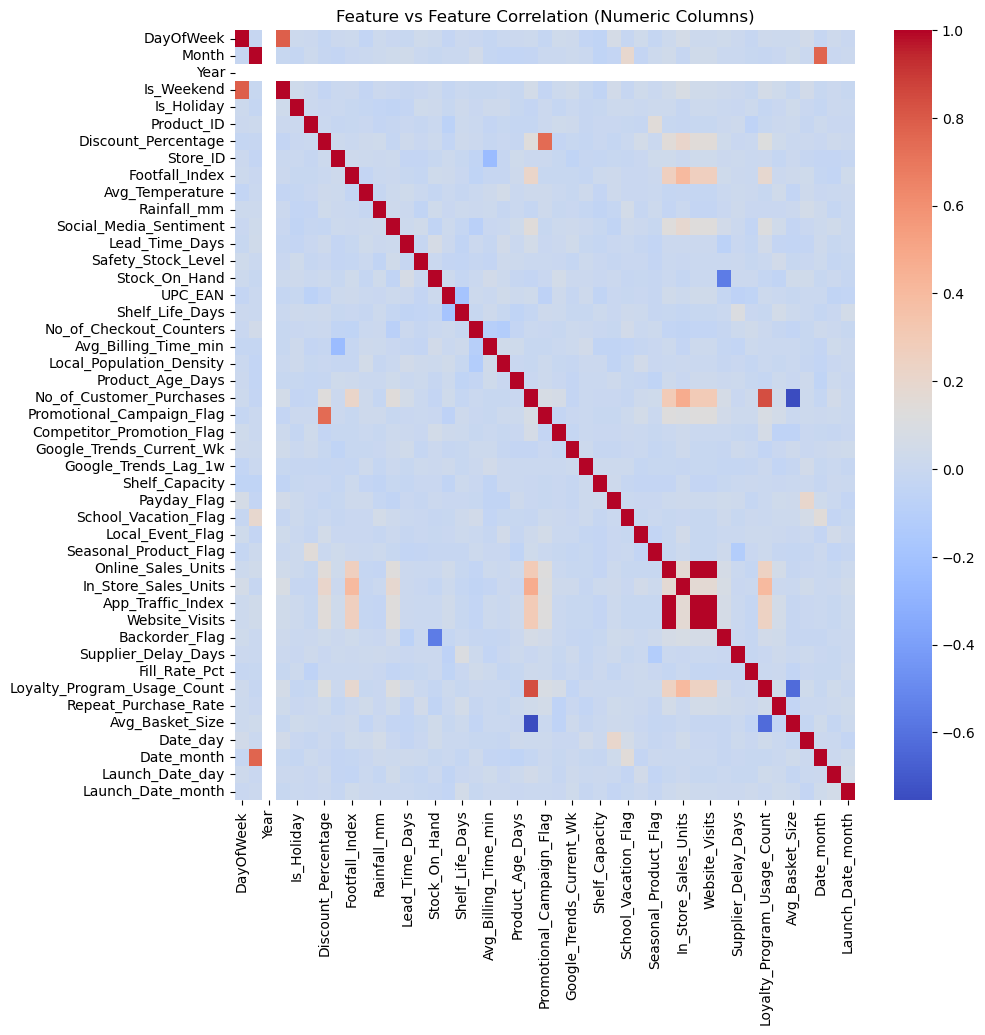

In [14]:
# Numeric columns in processed features
numeric_cols = X_proc.select_dtypes(include=['int64', 'float64']).columns

# Compute feature vs feature correlation
corr_matrix = X_proc[numeric_cols].corr()

# Display heatmap for numeric correlations
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Feature vs Feature Correlation (Numeric Columns)")
plt.show()

# Feature vs target correlation

Correlation with target:
 In_Store_Sales_Units           0.907218
Online_Sales_Units             0.563879
Website_Visits                 0.563876
App_Traffic_Index              0.563811
No_of_Customer_Purchases       0.526389
Footfall_Index                 0.444336
Loyalty_Program_Usage_Count    0.436604
Discount_Percentage            0.234250
Social_Media_Sentiment         0.216616
Promotional_Campaign_Flag      0.148517
Backorder_Flag                 0.091972
Is_Weekend                     0.083919
DayOfWeek                      0.057935
Local_Event_Flag               0.035876
Launch_Date_month              0.035350
UPC_EAN                        0.031440
Date_day                       0.029440
Payday_Flag                    0.028238
Repeat_Purchase_Rate           0.026742
Competitor_Promotion_Flag      0.022818
Store_ID                       0.022021
Google_Trends_Current_Wk       0.019210
Lead_Time_Days                 0.014998
Local_Population_Density       0.010330
Seasonal_Produ

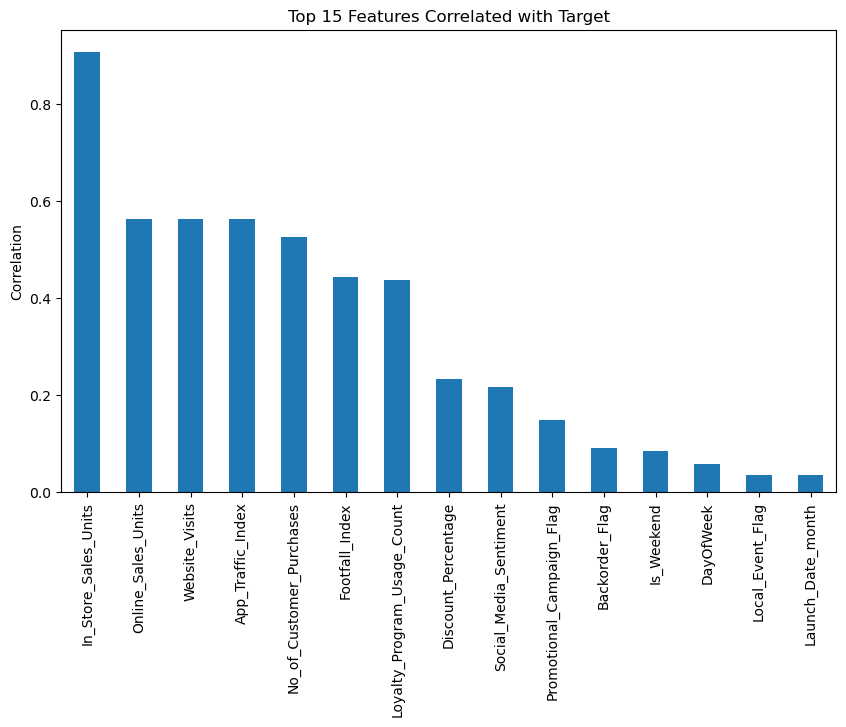

In [16]:
corr_with_target = X_proc[numeric_cols].corrwith(y).sort_values(ascending=False)
print("Correlation with target:\n", corr_with_target)
top_corr = corr_with_target.head(15)  # top 15 features
plt.figure(figsize=(10,6))
top_corr.plot(kind='bar')
plt.title("Top 15 Features Correlated with Target")
plt.ylabel("Correlation")
plt.show()

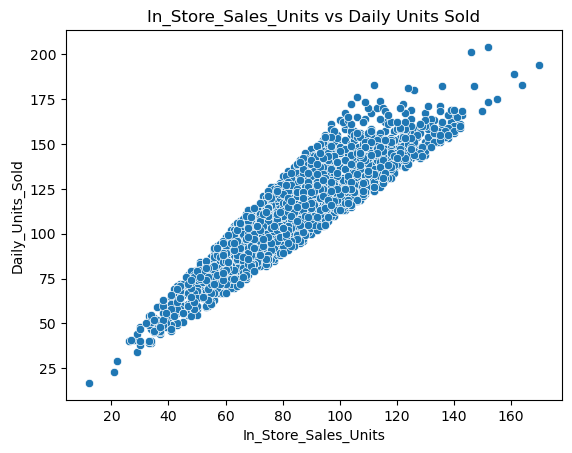

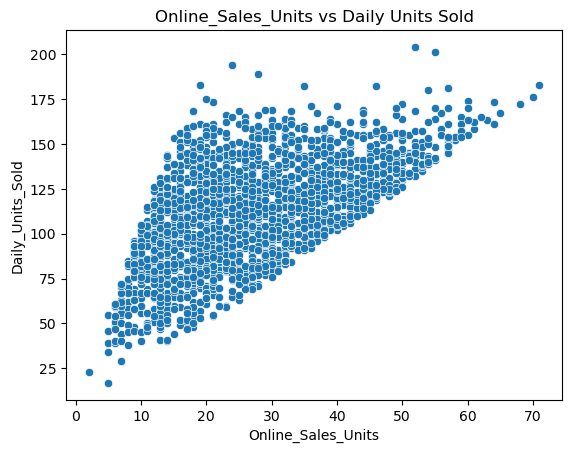

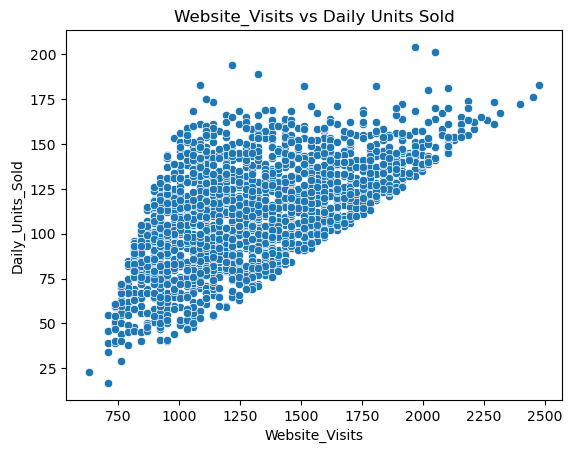

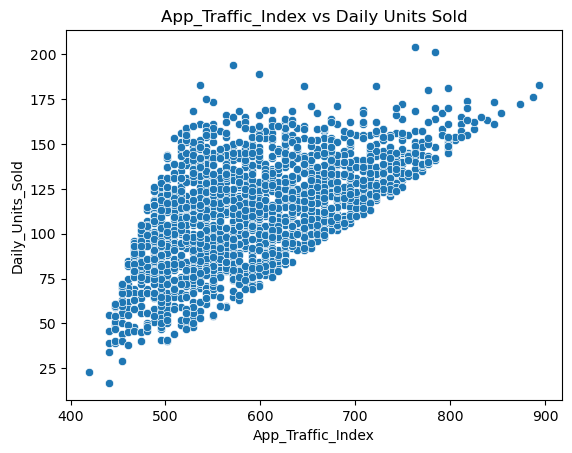

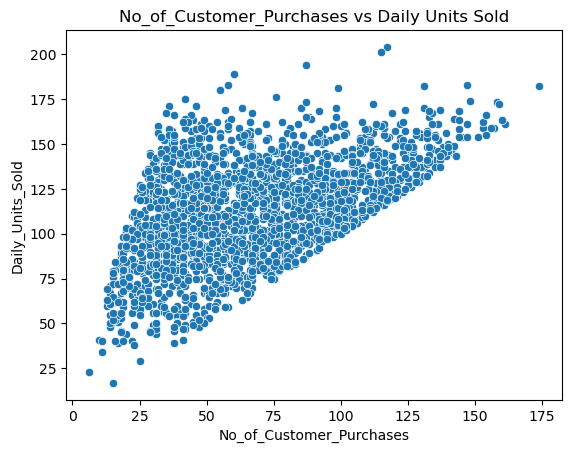

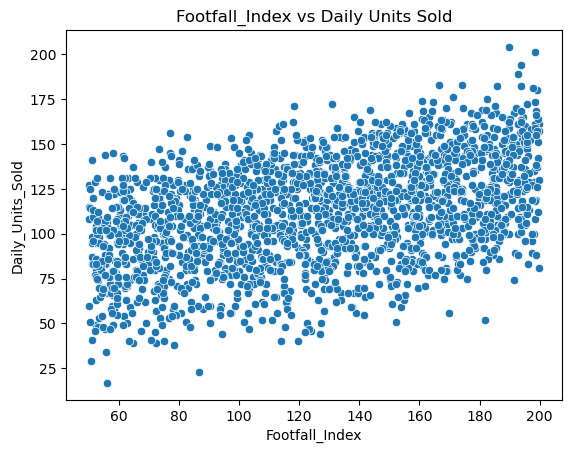

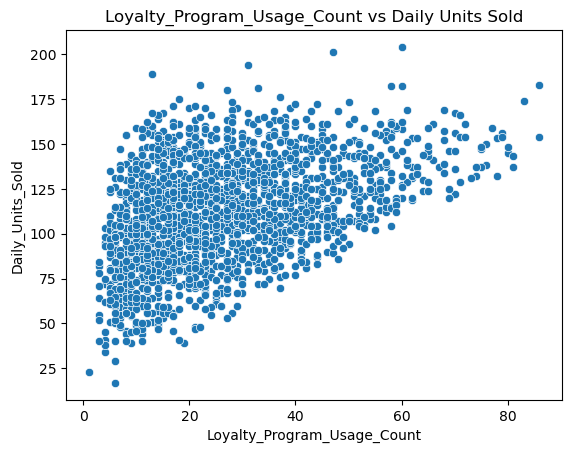

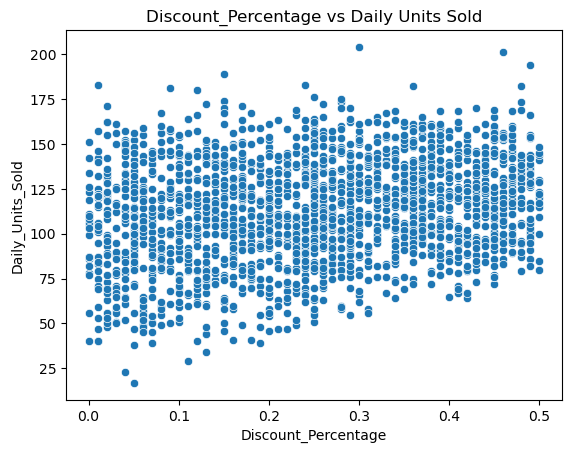

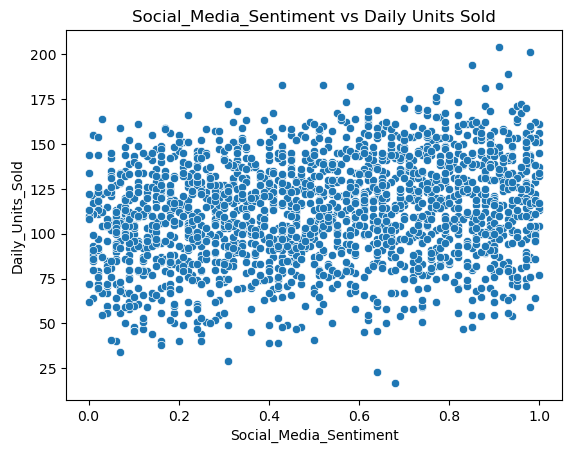

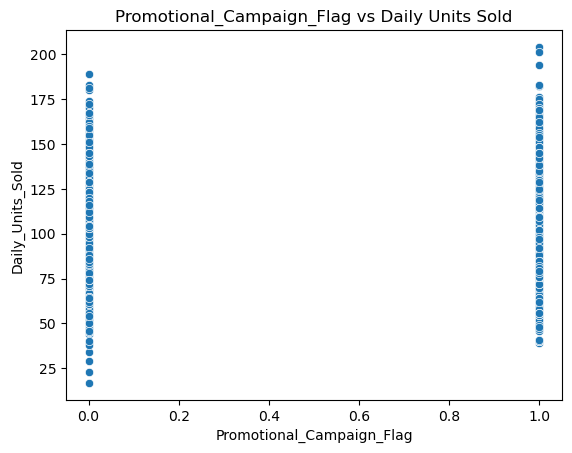

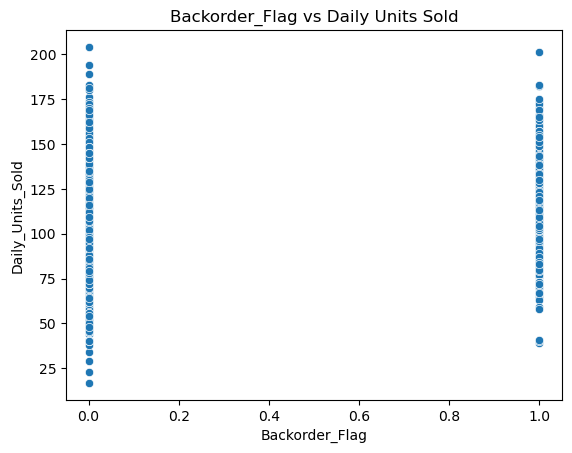

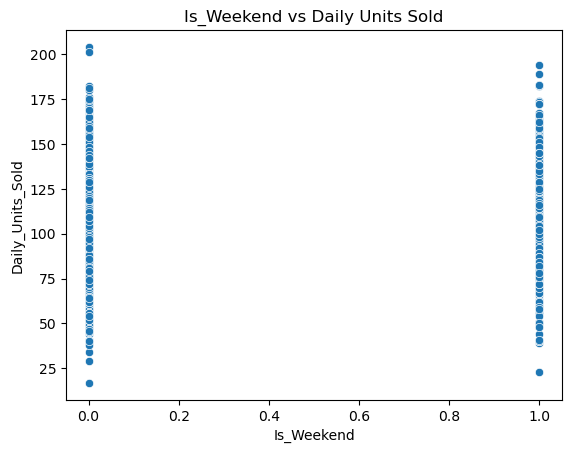

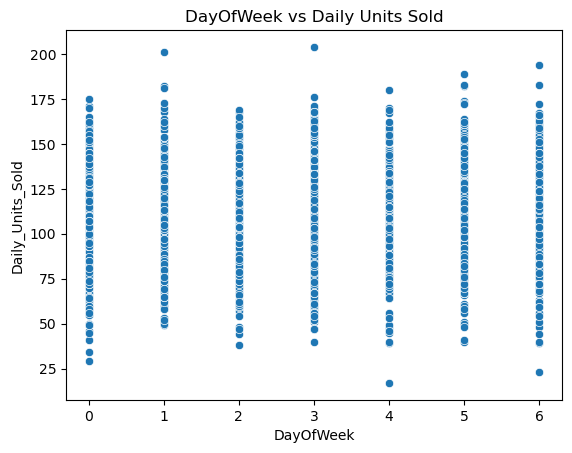

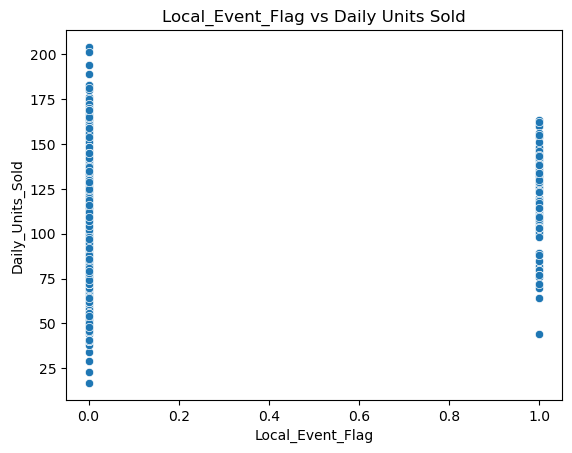

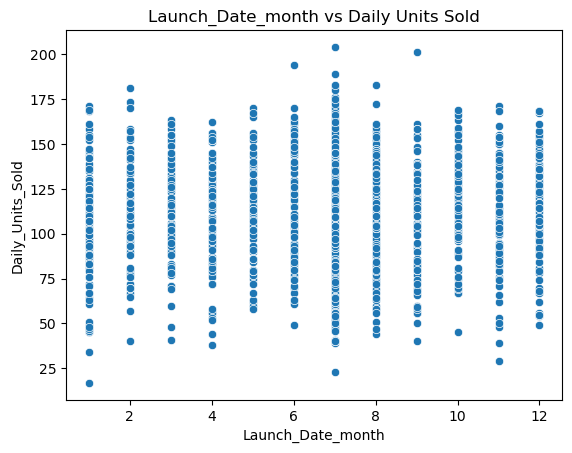

In [17]:
for feature in top_corr.index:
    
    sns.scatterplot(x=df_clean[feature], y=df_clean["Daily_Units_Sold"])
    
    plt.title(f"{feature} vs Daily Units Sold")
    plt.show()

# Statistical Significance Test

In [19]:
for feature in top_corr.index:

    corr, p_value = pearsonr(df_clean[feature], df_clean["Daily_Units_Sold"])

    print(f"Feature: {feature}")
    print("Correlation:", corr)
    print("P-value:", p_value)
    print("-------------------")

Feature: In_Store_Sales_Units
Correlation: 0.907218002145274
P-value: 0.0
-------------------
Feature: Online_Sales_Units
Correlation: 0.5638786372025508
P-value: 2.995953346368956e-168
-------------------
Feature: Website_Visits
Correlation: 0.5638761443998089
P-value: 3.0083285340458723e-168
-------------------
Feature: App_Traffic_Index
Correlation: 0.5638111032604703
P-value: 3.3498814446121547e-168
-------------------
Feature: No_of_Customer_Purchases
Correlation: 0.5263887650885438
P-value: 5.72514326952822e-143
-------------------
Feature: Footfall_Index
Correlation: 0.4443355578283776
P-value: 1.5108718448638038e-97
-------------------
Feature: Loyalty_Program_Usage_Count
Correlation: 0.4366037141591369
P-value: 7.135048601030394e-94
-------------------
Feature: Discount_Percentage
Correlation: 0.23425003079870363
P-value: 2.471098303969801e-26
-------------------
Feature: Social_Media_Sentiment
Correlation: 0.2166157928576501
P-value: 1.1500780851043418e-22
-------------------

# Feature Importance

In [21]:
X = df_clean.select_dtypes(include=['int64', 'float64']).drop("Daily_Units_Sold", axis=1)
y = df_clean["Daily_Units_Sold"]

model = RandomForestRegressor()

model.fit(X,y)

importance = pd.Series(model.feature_importances_, index=X.columns)

top5 = importance.sort_values(ascending=False).head(5)
print(top5)

In_Store_Sales_Units    0.837549
Website_Visits          0.055537
App_Traffic_Index       0.052196
Online_Sales_Units      0.050211
Footfall_Index          0.000213
dtype: float64


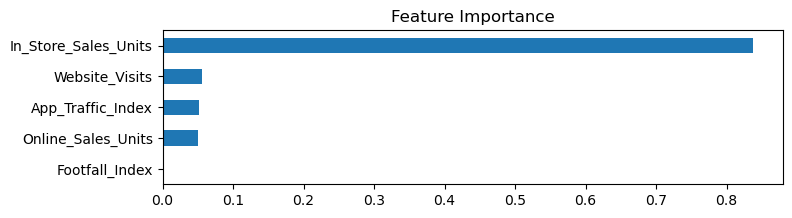

In [22]:
top5.sort_values().plot(kind='barh', figsize=(8,2))

plt.title("Feature Importance")
plt.show()

# Data preparation

In [24]:
target = 'Daily_Units_Sold'

# Step 1: ensure target exists
if target not in df.columns:
    raise ValueError("Target column missing!")

# Step 2: identify numeric features
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

# Step 3: remove target from features
numeric_features = [col for col in numeric_features if col != target]

# Step 4: correlation with target
target_corr = df[numeric_features + [target]].corr()[target].abs().sort_values(ascending=False)
print("Top correlations with target:\n", target_corr.head(10))

# Step 5: detect potential leakage (>0.9 correlation)
high_corr_features = target_corr[target_corr > 0.9].index.tolist()
high_corr_features = [f for f in high_corr_features if f != target]

# Step 6: flag conceptual leakage (like sales units columns)
conceptual_leakage = [col for col in numeric_features if 'sales_units' in col.lower()]

# Combine flags
leakage_features = list(set(high_corr_features + conceptual_leakage))

print("Potential leakage features (flagged, not dropped):", leakage_features)

# Step 7: Handle Date column
date_cols = [col for col in df.columns if 'date' in col.lower()]
if date_cols:
    print("Date columns detected (kept as-is for now):", date_cols)
    # Optional: convert to datetime if not done yet
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Step 8: Create df for modeling (excluding only leakage if desired)
df_model = df.drop(columns=leakage_features)  # optional: keep leakage if you want
print("Shape after handling leakage:", df_model.shape)

Top correlations with target:
 Daily_Units_Sold            1.000000
In_Store_Sales_Units        0.907218
Current_Price               0.795301
Base_Price                  0.749332
Competitor_Price            0.746378
Unit_Cost                   0.719368
Online_Sales_Units          0.563879
Website_Visits              0.563876
App_Traffic_Index           0.563811
No_of_Customer_Purchases    0.526389
Name: Daily_Units_Sold, dtype: float64
Potential leakage features (flagged, not dropped): ['In_Store_Sales_Units', 'Online_Sales_Units']
Date columns detected (kept as-is for now): ['Date', 'Launch_Date']
Shape after handling leakage: (2000, 56)


In [25]:
# -------------------------------
# Step 1: Copy dataframe for safety
# -------------------------------
X_proc = df_clean.copy()  # use df_clean since we are keeping all features

# -------------------------------
# Step 2: Identify target and features
# -------------------------------
target_col = 'Daily_Units_Sold'
if target_col not in X_proc.columns:
    raise ValueError(f"Target column {target_col} missing!")

y = X_proc[target_col]
X_proc.drop(columns=[target_col], inplace=True)

# -------------------------------
# Step 3: Detect numeric, categorical, text features
# -------------------------------
num_cols = X_proc.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_proc.select_dtypes(include=['object']).columns.tolist()

# Text heuristic: average string length > 15
text_cols = [col for col in cat_cols if X_proc[col].astype(str).apply(len).mean() > 15]

# Remaining categorical columns
cat_cols_proc = [col for col in cat_cols if col not in text_cols]

# -------------------------------
# Step 4: Fill missing values
# -------------------------------
for col in num_cols_proc:
    X_proc[col].fillna(X_proc[col].median(), inplace=True)

for col in cat_cols_proc:
    X_proc[col].fillna('missing', inplace=True)

for col in text_cols:
    X_proc[col].fillna('', inplace=True)

# -------------------------------
# Step 5: Scale numeric columns
# -------------------------------
scaler = StandardScaler()
X_proc[num_cols_proc] = scaler.fit_transform(X_proc[num_cols_proc])

# -------------------------------
# Step 6: Summary
# -------------------------------
print("Preprocessing complete.")
print("Processed shape:", X_proc.shape)
print("Numeric columns:", num_cols_proc)
print("Categorical columns (kept as-is):", cat_cols_proc)
print("Text columns (kept as-is):", text_cols)

Preprocessing complete.
Processed shape: (2000, 57)
Numeric columns: ['DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Is_Holiday', 'Product_ID', 'Discount_Percentage', 'Store_ID', 'Footfall_Index', 'Avg_Temperature', 'Rainfall_mm', 'Social_Media_Sentiment', 'Lead_Time_Days', 'Safety_Stock_Level', 'Stock_On_Hand', 'UPC_EAN', 'Shelf_Life_Days', 'No_of_Checkout_Counters', 'Avg_Billing_Time_min', 'Local_Population_Density', 'Product_Age_Days', 'No_of_Customer_Purchases', 'Promotional_Campaign_Flag', 'Competitor_Promotion_Flag', 'Google_Trends_Current_Wk', 'Google_Trends_Lag_1w', 'Shelf_Capacity', 'Payday_Flag', 'School_Vacation_Flag', 'Local_Event_Flag', 'Seasonal_Product_Flag', 'Online_Sales_Units', 'In_Store_Sales_Units', 'App_Traffic_Index', 'Website_Visits', 'Backorder_Flag', 'Supplier_Delay_Days', 'Fill_Rate_Pct', 'Loyalty_Program_Usage_Count', 'Repeat_Purchase_Rate', 'Avg_Basket_Size', 'Date_day', 'Date_month', 'Launch_Date_day', 'Launch_Date_month']
Categorical columns (kept as-is): ['

# PCA

In [27]:
# 1. Use the preprocessed dataframe
df_for_pca = X_proc.copy()

# 2. Select numeric features
numeric_features = df_for_pca.select_dtypes(include=np.number).columns.tolist()

# 3. Compute absolute correlation
corr_matrix = df_for_pca[numeric_features].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Find high correlation pairs
corr_threshold = 0.9
high_corr_pairs = [(numeric_features[i], numeric_features[j])
                   for i, j in zip(*np.where(upper_tri > corr_threshold))]

# 5. Flatten to unique features
high_corr_features = list(set([f for pair in high_corr_pairs for f in pair]))

# 6. Filter by variance
var_threshold = 0.01
high_var_features = df_for_pca[high_corr_features].var()
high_var_features = high_var_features[high_var_features > var_threshold].index.tolist()

print("Features selected for PCA:", high_var_features)

# 7. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_for_pca[high_var_features])

# 8. Apply PCA dynamically
pca = PCA(n_components=0.97, random_state=42)  # retain ~97% variance
pca_features = pca.fit_transform(X_scaled)

# 9. Drop original features and add PCA components
df_pca = df_for_pca.drop(columns=high_var_features).reset_index(drop=True)
pca_cols = [f"PCA_HighCorr_{i+1}" for i in range(pca_features.shape[1])]
df_pca[pca_cols] = pd.DataFrame(pca_features, columns=pca_cols)

# 10. PCA variance info
print("PCA explained variance ratios:", pca.explained_variance_ratio_)
print("Cumulative variance:", pca.explained_variance_ratio_.sum())
print("New shape after PCA:", df_pca.shape)

Features selected for PCA: ['Online_Sales_Units', 'Website_Visits', 'App_Traffic_Index']
PCA explained variance ratios: [0.99999722]
Cumulative variance: 0.9999972155125751
New shape after PCA: (2000, 55)


# Baseline encoding

In [29]:
# -------------------------------
# Step 1: Copy dataframe for safety
# -------------------------------
df_encoded = df_pca.copy()

# -------------------------------
# Step 2: Dynamically detect categorical/text columns
# -------------------------------
categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
text_cols = [col for col in categorical_cols if df_encoded[col].astype(str).apply(len).mean() > 15]
cat_cols_final = [col for col in categorical_cols if col not in text_cols]

# -------------------------------
# Step 3: Encode categorical columns with LabelEncoder
# -------------------------------
label_encoders = {}
for col in cat_cols_final:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print("Label encoding complete.")
print("Categorical columns encoded:", cat_cols_final)
print("Text columns (kept as-is):", text_cols)
print("Shape after encoding:", df_encoded.shape)

Label encoding complete.
Categorical columns encoded: ['Category', 'Store_Type', 'Festival_Type', 'Sub_Category', 'Brand_Name', 'Brand_Tier', 'Promotion_Type']
Text columns (kept as-is): ['Festival_Name', 'Product_Name']
Shape after encoding: (2000, 55)


# TF-IDF 

In [31]:
# -------------------------------
# Step 1: Copy dataframe for TF-IDF
# -------------------------------
df_tfidf = df_pca.copy()

# -------------------------------
# Step 2: Identify text columns dynamically
# -------------------------------
text_cols = df_tfidf.select_dtypes(include='object').columns.tolist()

# -------------------------------
# Step 3: Apply TF-IDF to each text column
# -------------------------------
tfidf_dfs = []

for col in text_cols:
    if df_tfidf[col].nunique() > 1:  # at least 2 unique values
        try:
            tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')  # accept numbers & words
            tfidf_matrix = tfidf.fit_transform(df_tfidf[col].astype(str))
            tfidf_df = pd.DataFrame(
                tfidf_matrix.toarray(),
                columns=[f"{col}_tfidf_{i}" for i in range(tfidf_matrix.shape[1])]
            )
            tfidf_dfs.append(tfidf_df)
        except ValueError as e:
            print(f"Skipping {col} due to TF-IDF error: {e}")
    else:
        print(f"Skipping {col} (only {df_tfidf[col].nunique()} unique value(s))")

# -------------------------------
# Step 4: Concatenate TF-IDF features with original dataframe
# -------------------------------
if tfidf_dfs:
    df_tfidf = pd.concat([df_tfidf.reset_index(drop=True)] + tfidf_dfs, axis=1)

print("TF-IDF vectorization complete.")
print("Text columns vectorized:", text_cols)
print("New shape:", df_tfidf.shape)

TF-IDF vectorization complete.
Text columns vectorized: ['Category', 'Store_Type', 'Festival_Name', 'Festival_Type', 'Product_Name', 'Sub_Category', 'Brand_Name', 'Brand_Tier', 'Promotion_Type']
New shape: (2000, 193)


# Word2Vec vectorization

In [33]:
# Copy df_pca (includes numeric + PCA features)
df_w2v = df_pca.copy()

# Identify text columns dynamically
text_cols = df_w2v.select_dtypes(include='object').columns.tolist()

# Word2Vec parameters
embedding_size = 50
w2v_window = 5
w2v_min_count = 1

for col in text_cols:
    if df_w2v[col].nunique() <= 1:
        print(f"Skipping {col} (only {df_w2v[col].nunique()} unique value(s))")
        continue
    
    # Tokenize each row
    sentences = df_w2v[col].astype(str).apply(word_tokenize).tolist()
    
    # Skip column if all entries are empty
    if not sentences or all(len(s) == 0 for s in sentences):
        continue
    
    # Train Word2Vec model
    w2v_model = Word2Vec(sentences, vector_size=embedding_size, window=w2v_window,
                         min_count=w2v_min_count, workers=4, seed=42)
    
    # Aggregate embeddings per row (mean of word vectors)
    embeddings = []
    for sent in sentences:
        vecs = [w2v_model.wv[word] for word in sent if word in w2v_model.wv]
        embeddings.append(np.mean(vecs, axis=0) if vecs else np.zeros(embedding_size))
    
    # Convert to dataframe and add to main df
    w2v_df = pd.DataFrame(embeddings, columns=[f"{col}_w2v_{i}" for i in range(embedding_size)])
    df_w2v = pd.concat([df_w2v, w2v_df], axis=1)

print("Word2Vec embeddings added.")
print("New shape:", df_w2v.shape)

Word2Vec embeddings added.
New shape: (2000, 505)


# GloVe vectorization

In [35]:
# Load pre-trained GloVe embeddings (100d)
glove_model = api.load("glove-wiki-gigaword-100")

# Copy df_pca to work on
df_glove = df_pca.copy()
text_cols = df_glove.select_dtypes(include='object').columns.tolist()

glove_features = []

for col in tqdm(text_cols, desc="GloVe embedding"):
    if df_glove[col].nunique() <= 1:
        print(f"Skipping {col} (only {df_glove[col].nunique()} unique value(s))")
        continue
    
    col_embeddings = []
    for text in df_glove[col].astype(str):
        tokens = word_tokenize(text)
        vecs = [glove_model[word] for word in tokens if word in glove_model]
        if vecs:
            col_embeddings.append(np.mean(vecs, axis=0))
        else:
            col_embeddings.append(np.zeros(glove_model.vector_size))
    
    col_emb_df = pd.DataFrame(col_embeddings, columns=[f"{col}_glove_{i}" for i in range(glove_model.vector_size)])
    glove_features.append(col_emb_df)

# Concatenate embeddings with the original dataframe
df_glove = pd.concat([df_glove] + glove_features, axis=1)

print("GloVe embeddings added.")
print("New shape:", df_glove.shape)

GloVe embedding: 100%|██████████| 9/9 [00:01<00:00,  4.57it/s]

GloVe embeddings added.
New shape: (2000, 955)


# Regression baseline model

In [37]:
def prepare_for_model(df_vec, target_col='Daily_Units_Sold'):
    
    # Target (from original clean df)
    y = df_clean[target_col].values
    
    # Features ONLY
    X = df_vec.copy()
    X = X.select_dtypes(include=np.number)
    
    # Safety: drop target if it somehow exists
    if target_col in X.columns:
        X = X.drop(columns=[target_col])
    
    return X, y

In [38]:
def evaluate_model(df_vec, target_col='Daily_Units_Sold'):
    X, y = prepare_for_model(df_vec, target_col)
    
    # -----------------------------
    # 90% train, 10% temp
    # -----------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.10, random_state=42
    )
    
    # -----------------------------
    # 5% val, 5% test
    # -----------------------------
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42
    )
    
    # Model
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    # -----------------------------
    # Predictions
    # -----------------------------
    y_train_pred = rf.predict(X_train)
    y_val_pred   = rf.predict(X_val)
    y_test_pred  = rf.predict(X_test)
    
    # -----------------------------
    # RMSE
    # -----------------------------
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse   = np.sqrt(mean_squared_error(y_val, y_val_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # -----------------------------
    # MAE
    # -----------------------------
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae   = mean_absolute_error(y_val, y_val_pred)
    test_mae  = mean_absolute_error(y_test, y_test_pred)
    
    # -----------------------------
    # R2
    # -----------------------------
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2   = r2_score(y_val, y_val_pred)
    test_r2  = r2_score(y_test, y_test_pred)
    
    return {
        "Train_R2": train_r2,
        "Val_R2": val_r2,
        "Test_R2": test_r2,
        
        "Train_RMSE": train_rmse,
        "Val_RMSE": val_rmse,
        "Test_RMSE": test_rmse,
        
        "Train_MAE": train_mae,
        "Val_MAE": val_mae,
        "Test_MAE": test_mae
    }

In [39]:
train_rows = []
val_rows = []
test_rows = []

for name, df_vec in [
    ('Categorical Encoding', df_encoded),
    ('TF-IDF', df_tfidf),
    ('Word2Vec', df_w2v),
    ('GloVe', df_glove)
]:
    metrics = evaluate_model(df_vec)
    
    # ---------------- Train ----------------
    train_rows.append({
        "Model": name,
        "R2": metrics["Train_R2"],
        "RMSE": metrics["Train_RMSE"],
        "MAE": metrics["Train_MAE"]
    })
    
    # ---------------- Validation ----------------
    val_rows.append({
        "Model": name,
        "R2": metrics["Val_R2"],
        "RMSE": metrics["Val_RMSE"],
        "MAE": metrics["Val_MAE"]
    })
    
    # ---------------- Test ----------------
    test_rows.append({
        "Model": name,
        "R2": metrics["Test_R2"],
        "RMSE": metrics["Test_RMSE"],
        "MAE": metrics["Test_MAE"]
    })

# Convert to DataFrames
train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)
test_df = pd.DataFrame(test_rows)

# Display
# train_df, val_df, test_df
def format_table(df, title):
    print(f"\n===== {title} =====\n")
    display(
        df.style.format({
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "R2": "{:.3f}"
        }).set_caption(title)
    )

# Display neatly
format_table(train_df, "TRAIN RESULTS")
format_table(val_df, "VALIDATION RESULTS")
format_table(test_df, "TEST RESULTS")


===== TRAIN RESULTS =====



,Model,R2,RMSE,MAE
0,Categorical Encoding,1.000,0.63,0.34
1,TF-IDF,1.000,0.63,0.34
2,Word2Vec,0.999,0.72,0.40
3,GloVe,0.999,0.66,0.37



===== VALIDATION RESULTS =====



,Model,R2,RMSE,MAE
0,Categorical Encoding,0.999,1.02,0.76
1,TF-IDF,0.998,1.08,0.77
2,Word2Vec,0.998,1.31,0.93
3,GloVe,0.998,1.18,0.84



===== TEST RESULTS =====



,Model,R2,RMSE,MAE
0,Categorical Encoding,0.998,1.04,0.79
1,TF-IDF,0.999,1.02,0.78
2,Word2Vec,0.998,1.20,0.91
3,GloVe,0.998,1.14,0.86


# Classification

In [41]:
# Copy the PCA-processed dataframe
df_model = df_pca.copy()
df_model['Daily_Units_Sold'] = df[target].reset_index(drop=True) 

n_combined_bins = 5

# Use qcut with duplicates dropped to avoid identical edges
df_model['Demand_Bin'] = pd.qcut(
    df_model['Daily_Units_Sold'],
    q=n_combined_bins,
    labels=False,
    duplicates='drop'
)

# Check the number of bins created and distribution
bin_counts = df_model['Demand_Bin'].value_counts().sort_index()
print("Number of bins created:", bin_counts.shape[0])
print("Samples per bin:")
print(bin_counts)

Number of bins created: 5
Samples per bin:
Demand_Bin
0    409
1    400
2    403
3    391
4    397
Name: count, dtype: int64


# Logistic regression

In [43]:
# ------------------------------
# Step 1: Function to retain numeric features only
# ------------------------------
def retain_numeric_features(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    return df[numeric_cols].copy()


def evaluate_logistic_with_val(df_features, target_col='Demand_Bin'):

    X = df_features.drop(columns=[target_col], errors='ignore')
    y = df_features[target_col]

    # -------------------------
    # Standardize features
    # -------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -------------------------
    # 90% train, 10% temp
    # -------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled, y, test_size=0.10, random_state=42, stratify=y
    )

    # -------------------------
    # 5% val, 5% test
    # -------------------------
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
    )

    # -------------------------
    # Model
    # -------------------------
    clf = LogisticRegression(
        # multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000
    )

    clf.fit(X_train, y_train)

    # -------------------------
    # Predictions
    # -------------------------
    y_train_pred = clf.predict(X_train)
    y_val_pred   = clf.predict(X_val)
    y_test_pred  = clf.predict(X_test)

    # -------------------------
    # Metrics (FULL)
    # -------------------------
    metrics = {
        # TRAIN
        "Train_Acc": accuracy_score(y_train, y_train_pred),
        "Train_F1": f1_score(y_train, y_train_pred, average='weighted'),

        # VALIDATION
        "Val_Acc": accuracy_score(y_val, y_val_pred),
        "Val_F1": f1_score(y_val, y_val_pred, average='weighted'),

        # TEST
        "Test_Acc": accuracy_score(y_test, y_test_pred),
        "Test_F1": f1_score(y_test, y_test_pred, average='weighted'),

        "Test_Report": classification_report(y_test, y_test_pred)
    }

    return metrics
    
# ------------------------------
# Step 3: Prepare numeric features for all vectorizations
# ------------------------------
df_encoded_num = retain_numeric_features(df_encoded)
df_tfidf_num   = retain_numeric_features(df_tfidf)
df_w2v_num     = retain_numeric_features(df_w2v)
df_glove_num   = retain_numeric_features(df_glove)

# Add the combined bins target
for df_vec in [df_encoded_num, df_tfidf_num, df_w2v_num, df_glove_num]:
    df_vec['Demand_Bin'] = df_model['Demand_Bin']

# ------------------------------
# Create dictionary of vectorizations
# ------------------------------
vectorizations = {
    'Categorical Encoding': df_encoded_num,
    'TF-IDF': df_tfidf_num,
    'Word2Vec': df_w2v_num,
    'GloVe': df_glove_num
}

# ------------------------------
# Step 4: Evaluate all vectorizations
# ------------------------------
results_logistic = {}
for name, df_vec in vectorizations.items():
    metrics = evaluate_logistic_with_val(df_vec)
    results_logistic[name] = metrics

# ------------------------------
# Step 5: Display results
# ------------------------------
train_rows = []
val_rows = []
test_rows = []

for name, metrics in results_logistic.items():

    # TRAIN
    train_rows.append({
        "Model": name,
        "Accuracy": metrics["Train_Acc"],
        "F1": metrics["Train_F1"]
    })

    # VALIDATION
    val_rows.append({
        "Model": name,
        "Accuracy": metrics["Val_Acc"],
        "F1": metrics["Val_F1"]
    })

    # TEST
    test_rows.append({
        "Model": name,
        "Accuracy": metrics["Test_Acc"],
        "F1": metrics["Test_F1"]
    })

train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)
test_df = pd.DataFrame(test_rows)

def format_table(df, title):
    print(f"\n===== {title} =====\n")
    display(
        df.style.format({
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "R2": "{:.3f}"
        }).set_caption(title)
    )

# Display neatly
format_table(train_df, "TRAIN RESULTS")
format_table(val_df, "VALIDATION RESULTS")
format_table(test_df, "TEST RESULTS")


===== TRAIN RESULTS =====



,Model,Accuracy,F1
0,Categorical Encoding,0.956111,0.956156
1,TF-IDF,0.967222,0.967213
2,Word2Vec,0.968333,0.968329
3,GloVe,0.953333,0.953290



===== VALIDATION RESULTS =====



,Model,Accuracy,F1
0,Categorical Encoding,0.930000,0.928962
1,TF-IDF,0.810000,0.809408
2,Word2Vec,0.840000,0.838758
3,GloVe,0.890000,0.888378



===== TEST RESULTS =====



,Model,Accuracy,F1
0,Categorical Encoding,0.940000,0.940488
1,TF-IDF,0.870000,0.872148
2,Word2Vec,0.850000,0.853330
3,GloVe,0.880000,0.881250


# Custom Deep learning model

In [45]:
# -----------------------------
# Unified Diamond DL Model for all vectorizations
# -----------------------------
def train_evaluate_unified_diamond(df_features, target_col='Demand_Bin',
                                   epochs=20, batch_size=32, dropout_rate=0.3):
    df_features = df_features.copy()
    X = df_features.drop(columns=[target_col], errors='ignore')
    y = df_features[target_col]
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # -----------------------------
    # 90% train, 10% temp
    # -----------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled, y, test_size=0.10, random_state=42, stratify=y
    )
    
    # -----------------------------
    # 5% val, 5% test
    # -----------------------------
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
    )
    input_dim = X_train.shape[1]
    n_classes = len(y.unique())
    
    # Diamond-shaped network
    model = Sequential(name="UnifiedDiamondDL")
    model.add(Dense(input_dim*2, activation='relu', input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(input_dim*3, activation='gelu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(input_dim*4, activation='swish'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(input_dim*2, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(input_dim, activation='relu'))
    model.add(BatchNormalization())
    
    model.add(Dense(n_classes, activation='softmax'))
    
    # Compile
    model.compile(optimizer=Adam(0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    # -------------------------
    # Evaluate
    # -------------------------
    train_pred = model.predict(X_train, verbose=0).argmax(axis=1)
    val_pred   = model.predict(X_val, verbose=0).argmax(axis=1)
    test_pred  = model.predict(X_test, verbose=0).argmax(axis=1)
    
    # -------------------------
    # Train metrics
    # -------------------------
    train_acc = accuracy_score(y_train, train_pred)
    train_f1  = f1_score(y_train, train_pred, average='weighted')
    
    # -------------------------
    # Validation metrics
    # -------------------------
    val_acc = accuracy_score(y_val, val_pred)
    val_f1  = f1_score(y_val, val_pred, average='weighted')
    
    # -------------------------
    # Test metrics
    # -------------------------
    test_acc = accuracy_score(y_test, test_pred)
    test_f1  = f1_score(y_test, test_pred, average='weighted')
    
    report = classification_report(y_test, test_pred)
    
    metrics = {
        "Train_Accuracy": train_acc,
        "Train_F1": train_f1,
        
        "Val_Accuracy": val_acc,
        "Val_F1": val_f1,
        
        "Test_Accuracy": test_acc,
        "Test_F1": test_f1,
        
        "Report": report
    }
    return metrics, model, history

In [46]:
vectorizations = {
    'Categorical Encoding': df_encoded_num,
    'TF-IDF': df_tfidf_num,
    'Word2Vec': df_w2v_num,
    'GloVe': df_glove_num
}

results_unified_dl = {}

for name, df_vec in vectorizations.items():
    metrics, model, history = train_evaluate_unified_diamond(
        df_vec,
        epochs=20
    )
    
    results_unified_dl[name] = metrics

train_rows = []
val_rows = []
test_rows = []

for name, metrics in results_unified_dl.items():

    # TRAIN
    train_rows.append({
        "Model": name,
        "Accuracy": metrics["Train_Accuracy"],
        "F1": metrics["Train_F1"]
    })

    # VALIDATION
    val_rows.append({
        "Model": name,
        "Accuracy": metrics["Val_Accuracy"],
        "F1": metrics["Val_F1"]
    })

    # TEST
    test_rows.append({
        "Model": name,
        "Accuracy": metrics["Test_Accuracy"],
        "F1": metrics["Test_F1"]
    })

train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)
test_df = pd.DataFrame(test_rows)

def format_table(df, title):
    print(f"\n===== {title} =====\n")
    display(
        df.style.format({
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "R2": "{:.3f}"
        }).set_caption(title)
    )

# Display neatly
format_table(train_df, "TRAIN RESULTS")
format_table(val_df, "VALIDATION RESULTS")
format_table(test_df, "TEST RESULTS")


===== TRAIN RESULTS =====



,Model,Accuracy,F1
0,Categorical Encoding,0.962222,0.962083
1,TF-IDF,0.987222,0.987159
2,Word2Vec,0.922778,0.922803
3,GloVe,0.845556,0.847348



===== VALIDATION RESULTS =====



,Model,Accuracy,F1
0,Categorical Encoding,0.850000,0.845471
1,TF-IDF,0.770000,0.770127
2,Word2Vec,0.700000,0.702045
3,GloVe,0.680000,0.671561



===== TEST RESULTS =====



,Model,Accuracy,F1
0,Categorical Encoding,0.910000,0.910689
1,TF-IDF,0.690000,0.701338
2,Word2Vec,0.630000,0.632319
3,GloVe,0.720000,0.715164


# DL regression

In [48]:
# -----------------------------
# Unified Diamond DL Model (Regression)
# -----------------------------
def train_evaluate_unified_diamond_regression(
    df_features,
    target_col='Daily_Units_Sold',
    epochs=20,
    batch_size=32,
    dropout_rate=0.3
):

    X = df_features.drop(columns=[target_col])
    y = df_features[target_col]

    # -------------------------
    # Standardize features
    # -------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)


    # -----------------------------
    # 90% train, 10% temp
    # -----------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled, y, test_size=0.10, random_state=42
    )
    
    # -----------------------------
    # 5% val, 5% test
    # -----------------------------
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42
    )

    input_dim = X_train.shape[1]

    # -------------------------
    # Diamond-shaped regression network
    # -------------------------
    model = Sequential(name="UnifiedDiamondDL_Regression")

    model.add(Dense(input_dim * 2, activation='relu', input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    model.add(Dense(input_dim * 3, activation='gelu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    model.add(Dense(input_dim * 4, activation='swish'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    model.add(Dense(input_dim * 2, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    model.add(Dense(input_dim, activation='relu'))
    model.add(BatchNormalization())

    # -------------------------
    # Regression output layer
    # -------------------------
    model.add(Dense(1, activation='linear'))

    # -------------------------
    # Compile (REGRESSION LOSS)
    # -------------------------
    model.compile(
        optimizer=Adam(0.001),
        loss='mse',
        metrics=['mae']
    )

    # -------------------------
    # Train
    # -------------------------
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    # -------------------------
    # Predictions
    # -------------------------
    y_train_pred = model.predict(X_train, verbose=0).flatten()
    y_val_pred   = model.predict(X_val, verbose=0).flatten()
    y_test_pred  = model.predict(X_test, verbose=0).flatten()

    # -------------------------
    # Metrics
    # -------------------------

    metrics = {
    # ---------------- TRAIN ----------------
    "Train_MAE": mean_absolute_error(y_train, y_train_pred),
    "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
    "Train_R2": r2_score(y_train, y_train_pred),

    # ---------------- VAL ----------------
    "Val_MAE": mean_absolute_error(y_val, y_val_pred),
    "Val_RMSE": np.sqrt(mean_squared_error(y_val, y_val_pred)),
    "Val_R2": r2_score(y_val, y_val_pred),

    # ---------------- TEST ----------------
    "Test_MAE": mean_absolute_error(y_test, y_test_pred),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    "Test_R2": r2_score(y_test, y_test_pred),
    }
    return metrics, model, history

In [49]:
def retain_numeric_features(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    return df[numeric_cols].copy()
    
# ------------------------------
# Prepare numeric features for all vectorizations
# ------------------------------
df_encoded_num = retain_numeric_features(df_encoded)
df_tfidf_num   = retain_numeric_features(df_tfidf)
df_w2v_num     = retain_numeric_features(df_w2v)
df_glove_num   = retain_numeric_features(df_glove)


# Add the combined bins target
for df_vec in [df_encoded_num, df_tfidf_num, df_w2v_num, df_glove_num]:
    df_vec['Daily_Units_Sold'] = df_model['Daily_Units_Sold']

vectorizations = {
    'Categorical Encoding': df_encoded_num,
    'TF-IDF': df_tfidf_num,
    'Word2Vec': df_w2v_num,
    'GloVe': df_glove_num
}


results_unified_dl = {}

# -------------------------
# Train models
# -------------------------
for name, df_vec in vectorizations.items():
    metrics, model, history = train_evaluate_unified_diamond_regression(
        df_vec,
        target_col='Daily_Units_Sold',
        epochs=20
    )
    
    results_unified_dl[name] = metrics


# -------------------------
# Build tables
# -------------------------
train_rows = []
val_rows = []
test_rows = []

for name, metrics in results_unified_dl.items():

    # TRAIN
    train_rows.append({
        "Model": name,
        "MAE": metrics["Train_MAE"],
        "RMSE": metrics["Train_RMSE"],
        "R2": metrics["Train_R2"]
    })

    # VALIDATION
    val_rows.append({
        "Model": name,
        "MAE": metrics["Val_MAE"],
        "RMSE": metrics["Val_RMSE"],
        "R2": metrics["Val_R2"]
    })

    # TEST
    test_rows.append({
        "Model": name,
        "MAE": metrics["Test_MAE"],
        "RMSE": metrics["Test_RMSE"],
        "R2": metrics["Test_R2"]
    })


# -------------------------
# Convert to DataFrames
# -------------------------
train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)
test_df = pd.DataFrame(test_rows)

# -------------------------
# Display
# -------------------------
# train_df, val_df, test_df

def format_table(df, title):
    print(f"\n===== {title} =====\n")
    display(
        df.style.format({
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "R2": "{:.3f}"
        }).set_caption(title)
    )

# Display neatly
format_table(train_df, "TRAIN RESULTS")
format_table(val_df, "VALIDATION RESULTS")
format_table(test_df, "TEST RESULTS")


===== TRAIN RESULTS =====



,Model,MAE,RMSE,R2
0,Categorical Encoding,16.48,16.83,0.656
1,TF-IDF,3.09,4.20,0.979
2,Word2Vec,2.99,5.03,0.969
3,GloVe,3.10,5.63,0.962



===== VALIDATION RESULTS =====



,Model,MAE,RMSE,R2
0,Categorical Encoding,16.14,16.52,0.639
1,TF-IDF,3.28,4.35,0.975
2,Word2Vec,4.18,9.07,0.891
3,GloVe,3.80,7.80,0.920



===== TEST RESULTS =====



,Model,MAE,RMSE,R2
0,Categorical Encoding,16.29,16.73,0.609
1,TF-IDF,2.83,3.74,0.980
2,Word2Vec,3.72,7.68,0.918
3,GloVe,2.98,4.82,0.968


# Pre trained transformer

In [51]:
# ============================================
# LOAD DATA
# ============================================
df_model = df.copy()
target = "Daily_Units_Sold"

# ============================================
# BINNING (CLASS LABEL CREATION)
# ============================================
n_bins = 5

df_model["Demand_Bin"] = pd.qcut(
    df_model[target],
    q=n_bins,
    labels=False,
    duplicates="drop"
)

y = df_model["Demand_Bin"]

# ============================================
# SPLIT FEATURES
# ============================================
X = df_model.drop(columns=[target, "Demand_Bin"])

# ============================================
# SAFE PREPROCESSING
# ============================================
def preprocess(df):
    df = df.copy()

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna("")

    # convert datetime safely
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].map(lambda x: str(x))

    # convert object columns to string (for BERT)
    for col in df.columns:
        df[col] = df[col].astype(str)

    return df

X = preprocess(X)

# ============================================
# DISTILBERT SETUP (NO TRAINING)
# ============================================
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = DistilBertModel.from_pretrained("distilbert-base-uncased")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
bert_model.eval()

# ============================================
# CREATE TEXT REPRESENTATION
# ============================================
def row_to_text(row):
    return " ".join(row.values)

# ============================================
# BERT EMBEDDINGS FUNCTION
# ============================================
def get_bert_embeddings(text_list, batch_size=16):
    embeddings = []

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = bert_model(**inputs)

        # CLS token embedding
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

# ============================================
# CREATE TEXT INPUT FOR BERT
# ============================================
text_data = X.apply(row_to_text, axis=1).tolist()

print("Generating DistilBERT embeddings... (this may take time)")
bert_embeddings = get_bert_embeddings(text_data)

# ============================================
# OPTIONAL: ADD NUMERIC FEATURES TOO
# ============================================
numeric_X = df_model.select_dtypes(include=[np.number]).drop(columns=[target, "Demand_Bin"], errors="ignore")

numeric_X = numeric_X.fillna(0).values

# ALIGN SHAPES SAFELY
min_len = min(len(bert_embeddings), len(numeric_X))

X_final = np.hstack([
    bert_embeddings[:min_len],
    numeric_X[:min_len]
])

y_final = y[:min_len]

# ============================================
# TRAIN TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.05,
    random_state=42,
    stratify=y_final
)

# ============================================
# XGBOOST CLASSIFIER
# ============================================
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y_final)),
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

# ============================================
# PREDICTION
# ============================================
y_pred = xgb.predict(X_test)

print("\n===== DISTILBERT + XGBOOST RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Generating DistilBERT embeddings... (this may take time)

===== DISTILBERT + XGBOOST RESULTS =====
Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.95      0.95      0.95        20
           2       0.90      0.90      0.90        20
           3       0.85      0.85      0.85        20
           4       0.95      0.90      0.92        20

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



# Pre trained regression

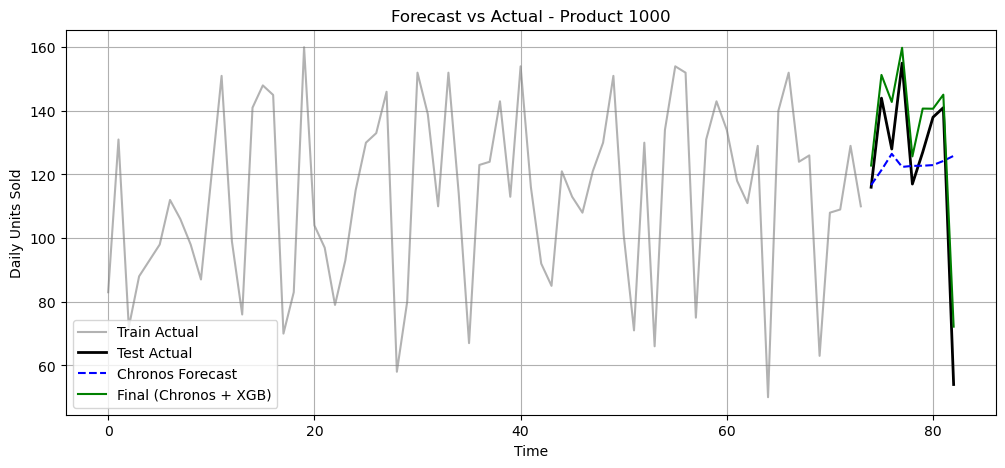

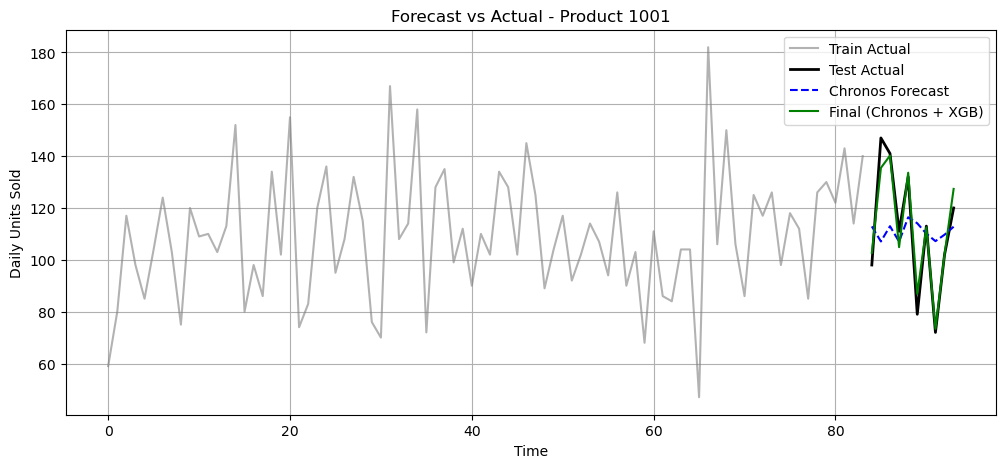

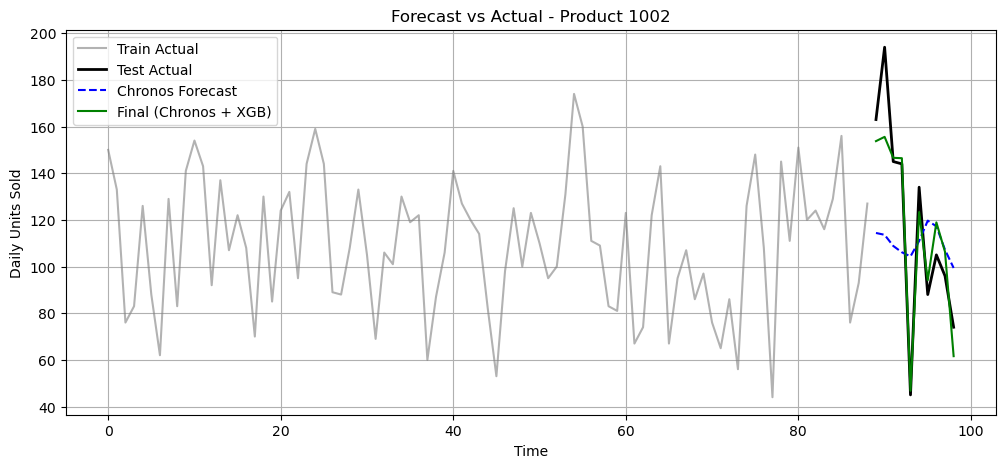

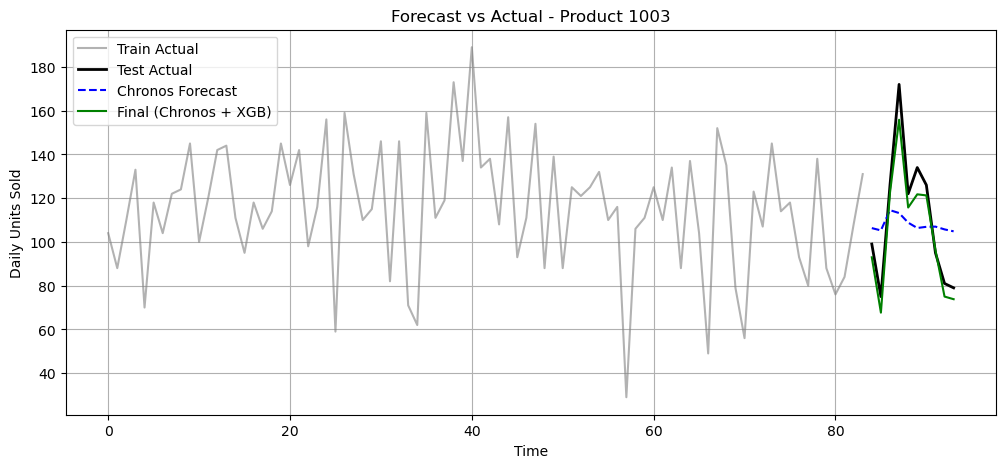

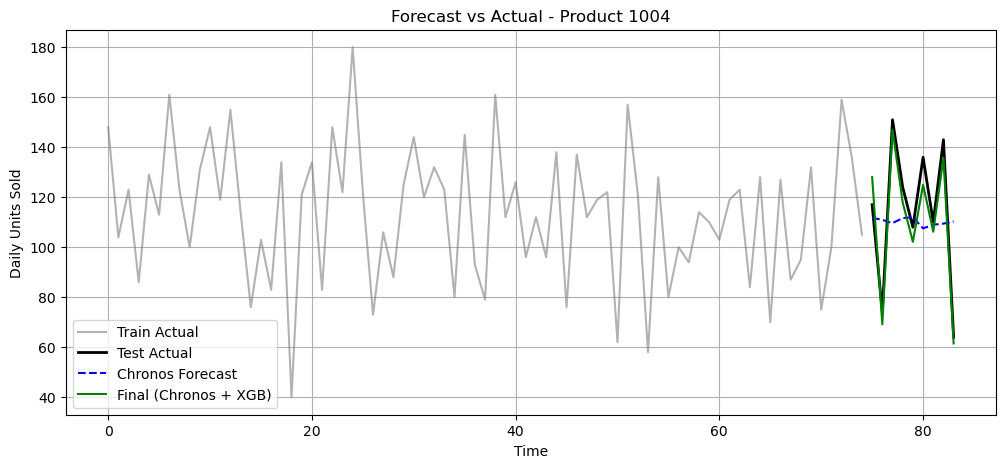

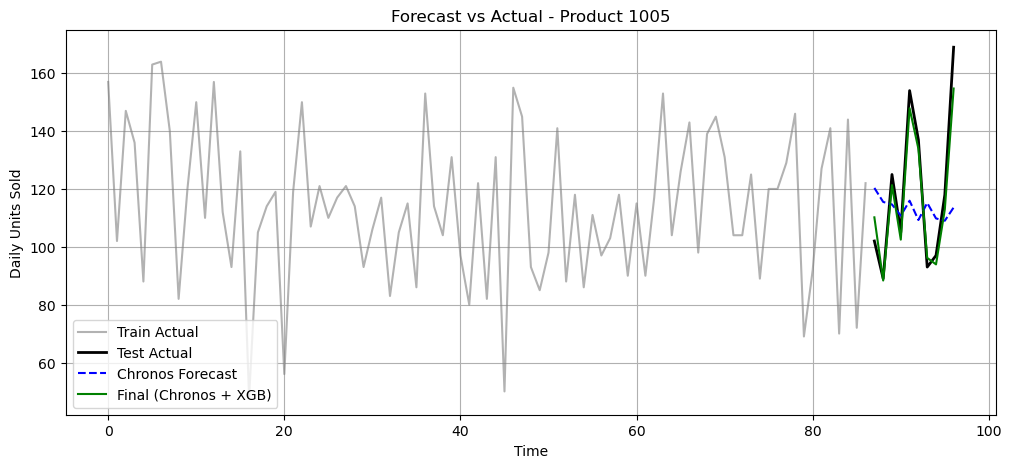

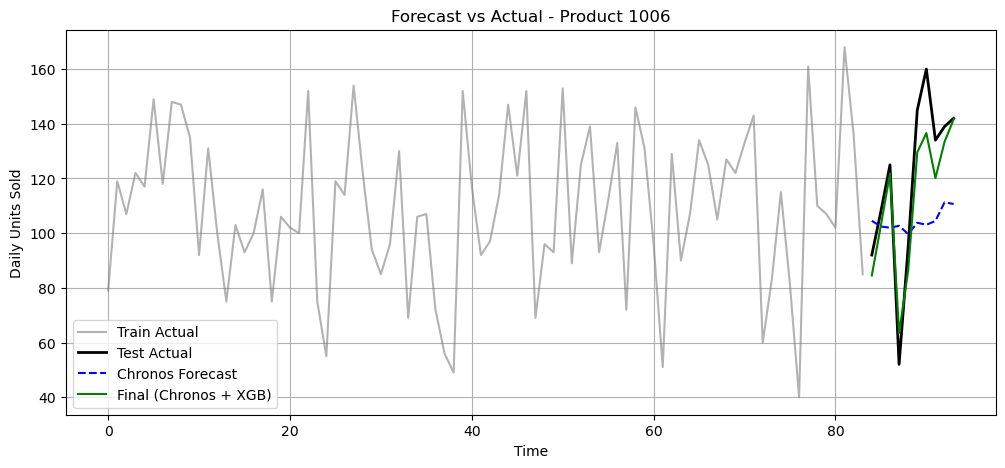

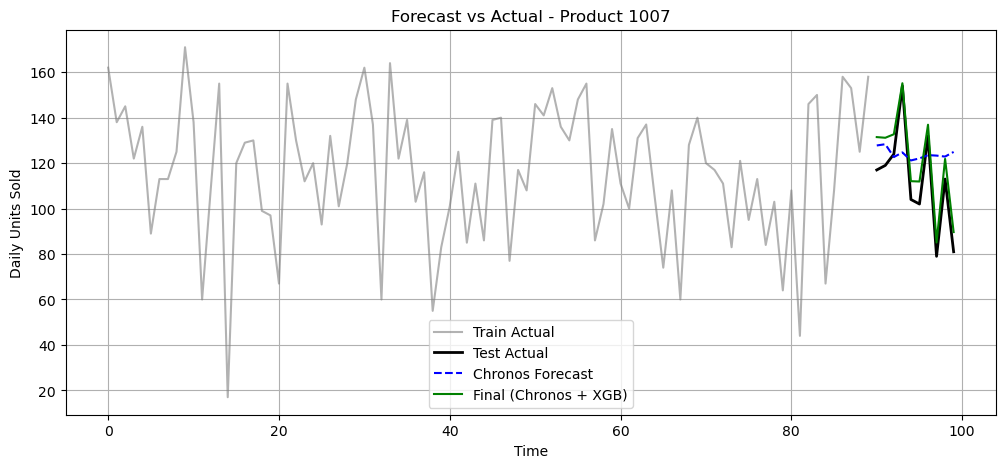

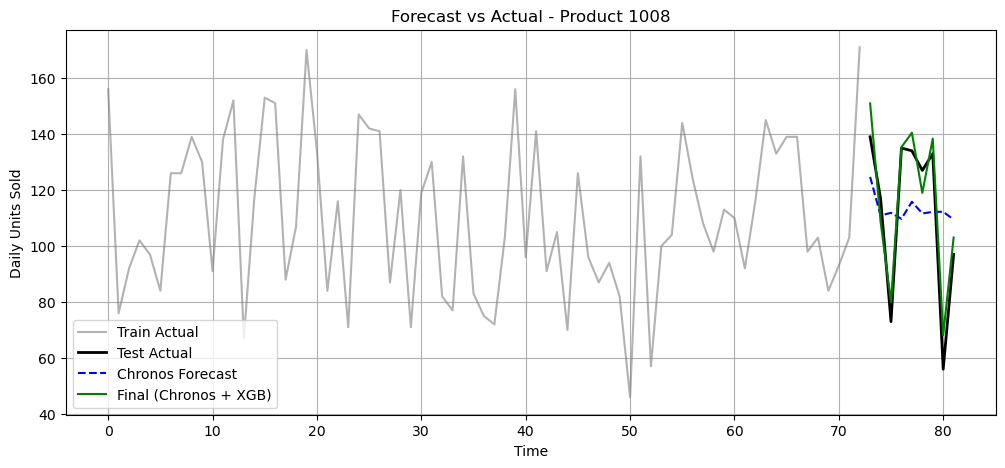

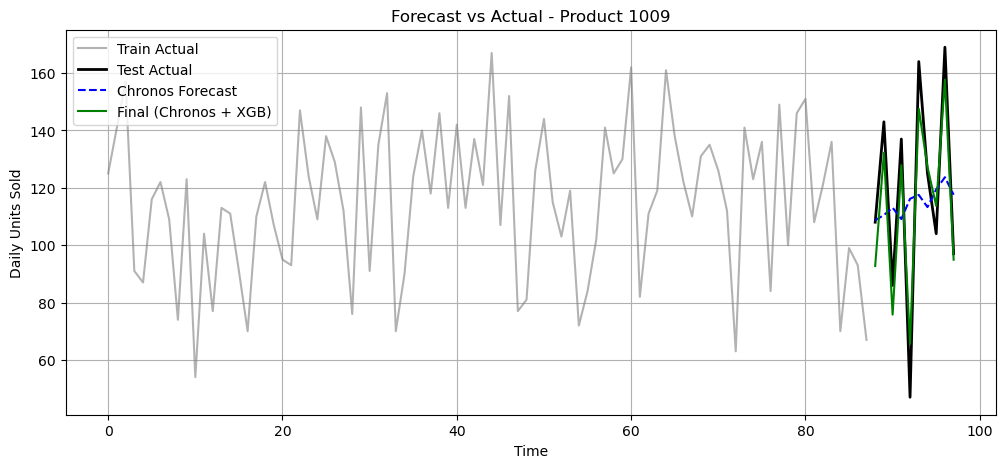

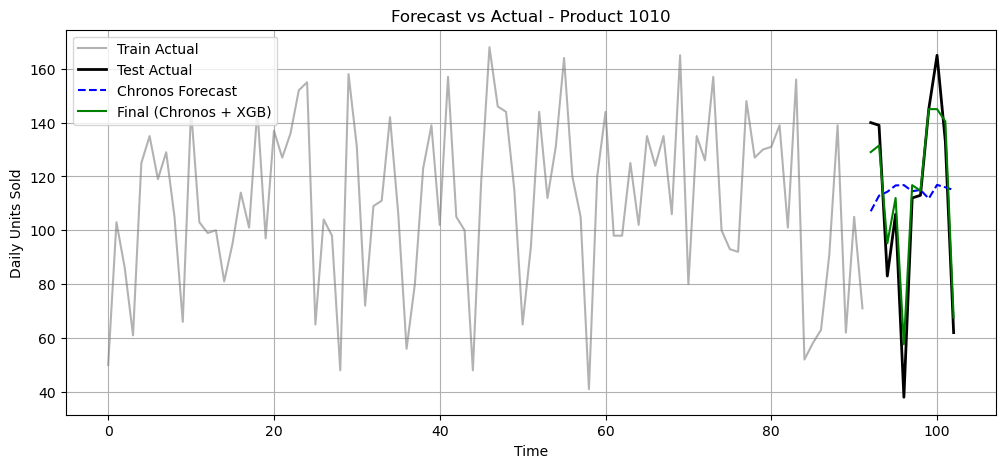

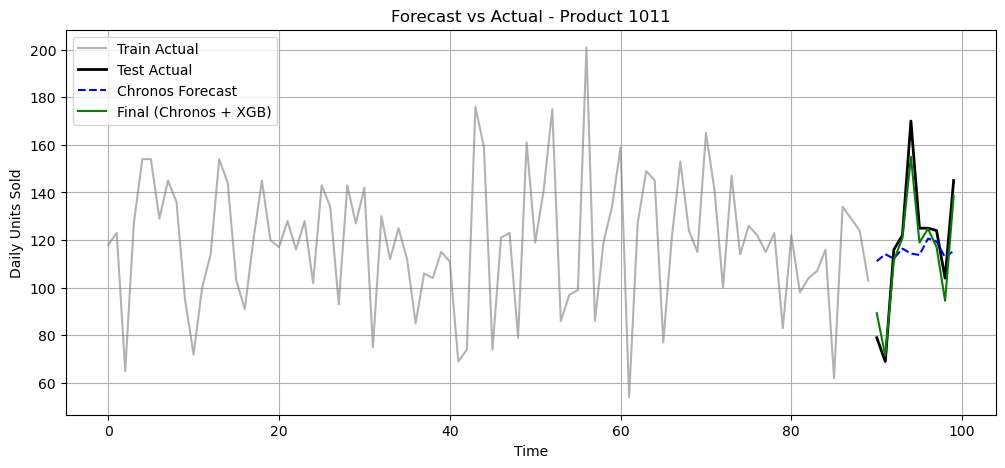

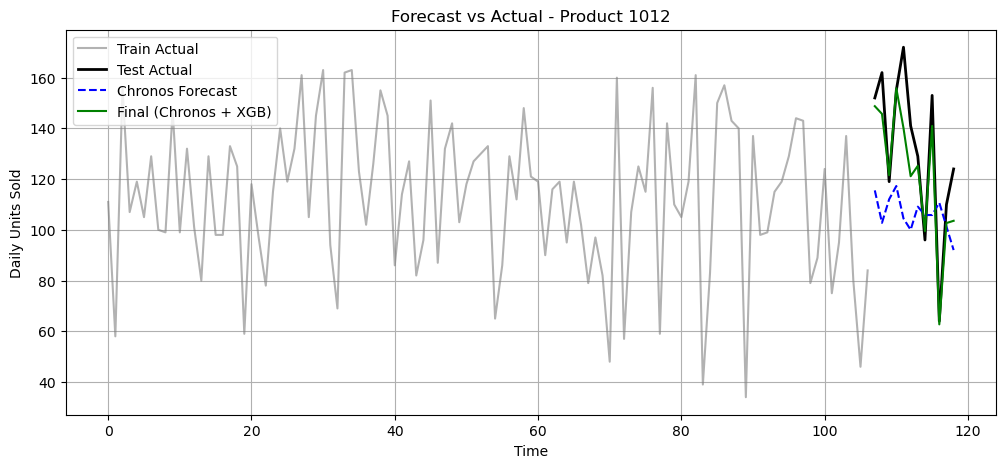

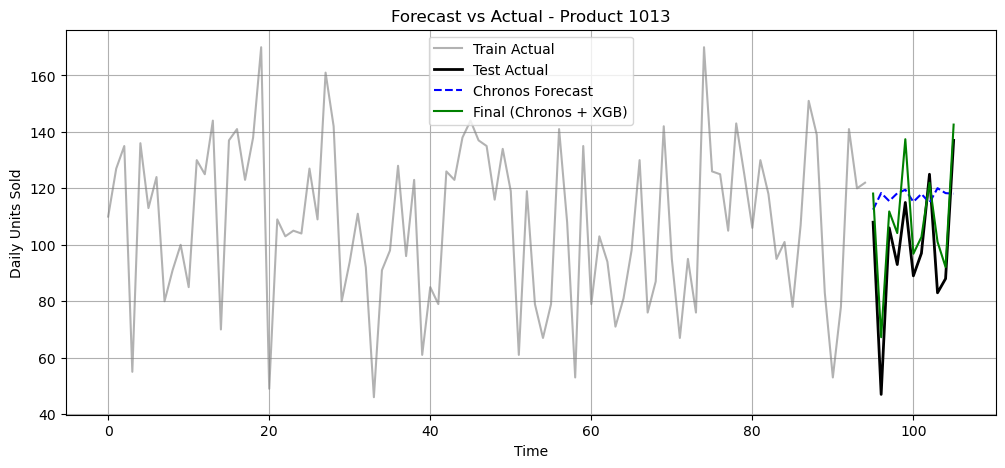

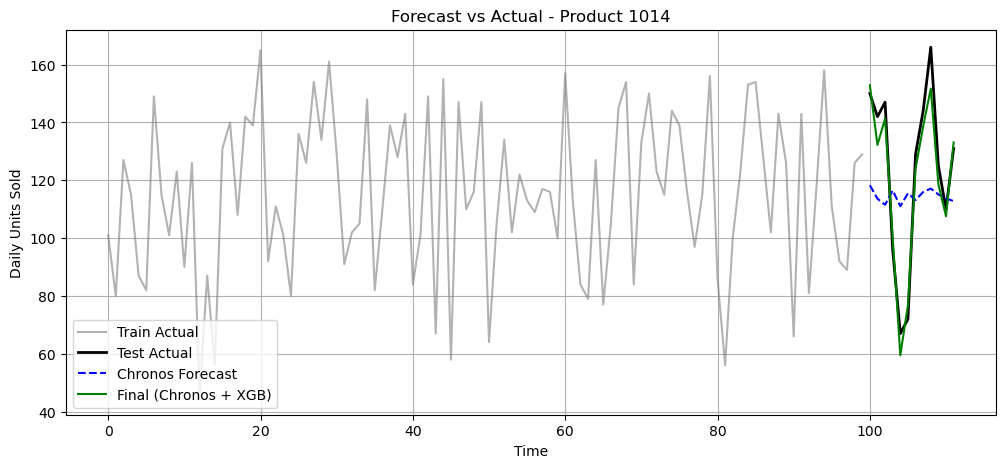

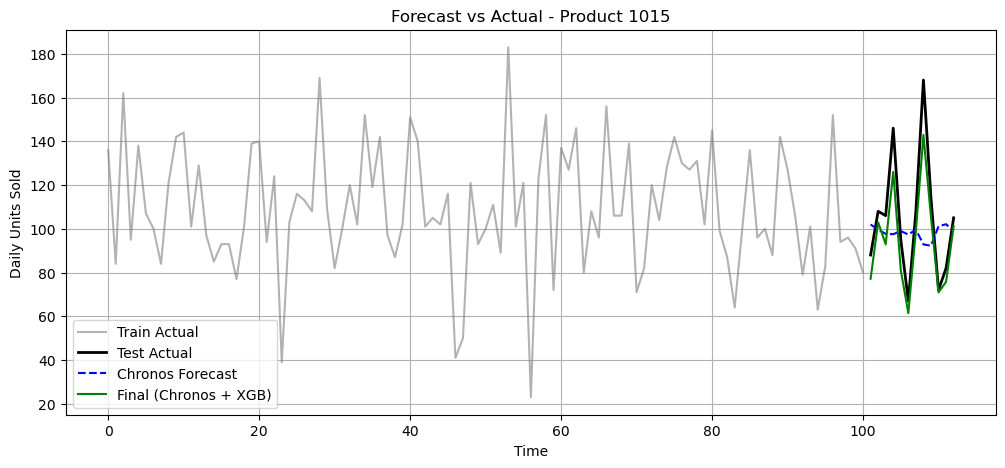

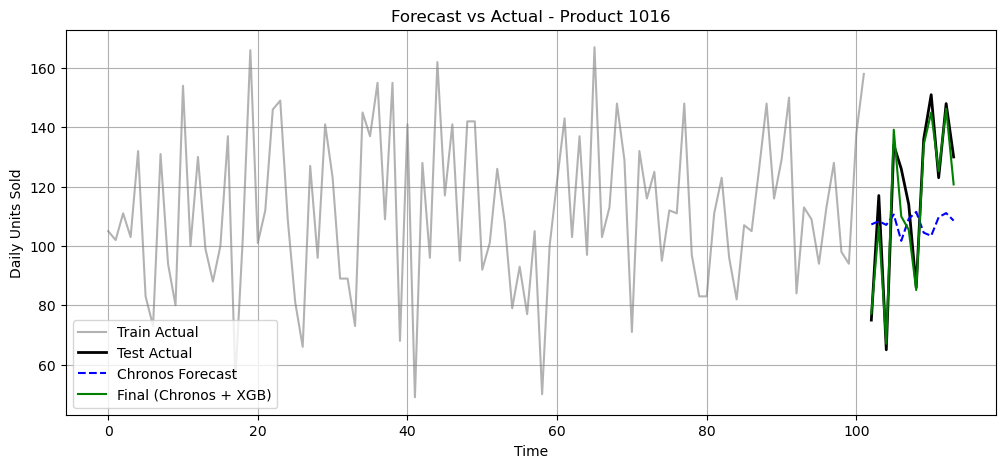

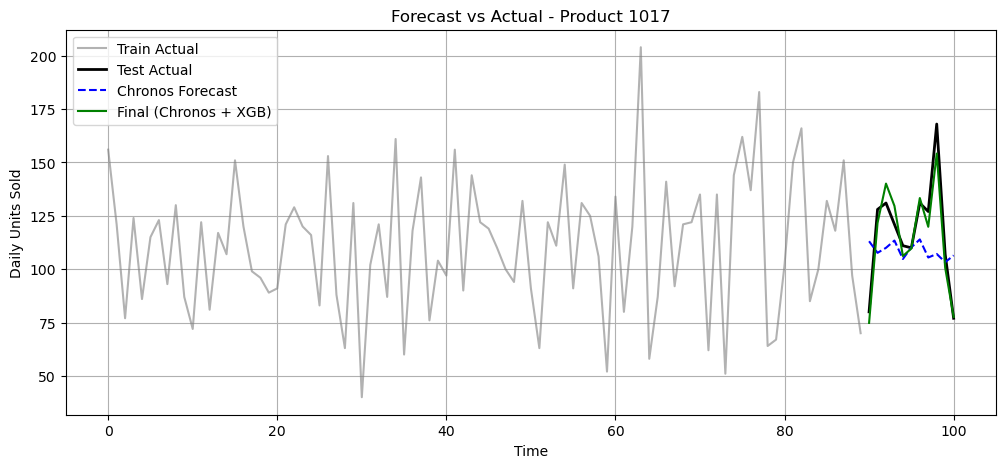

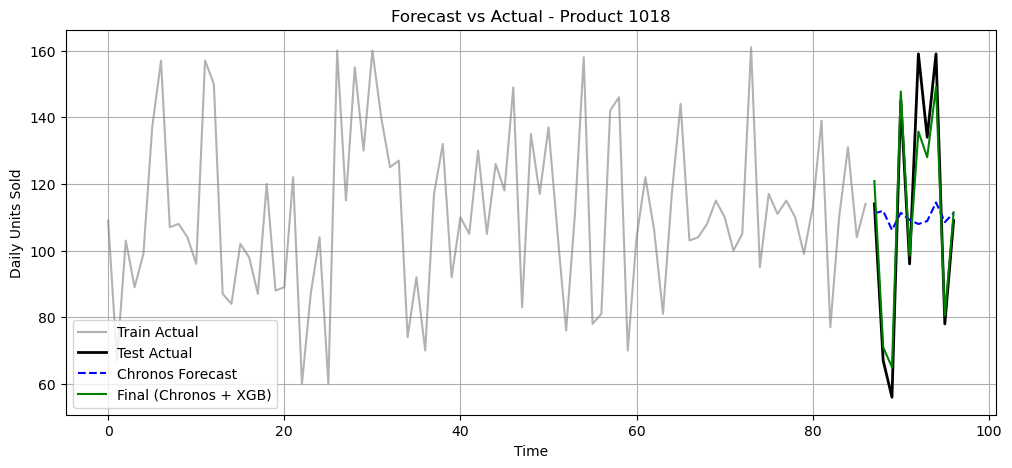

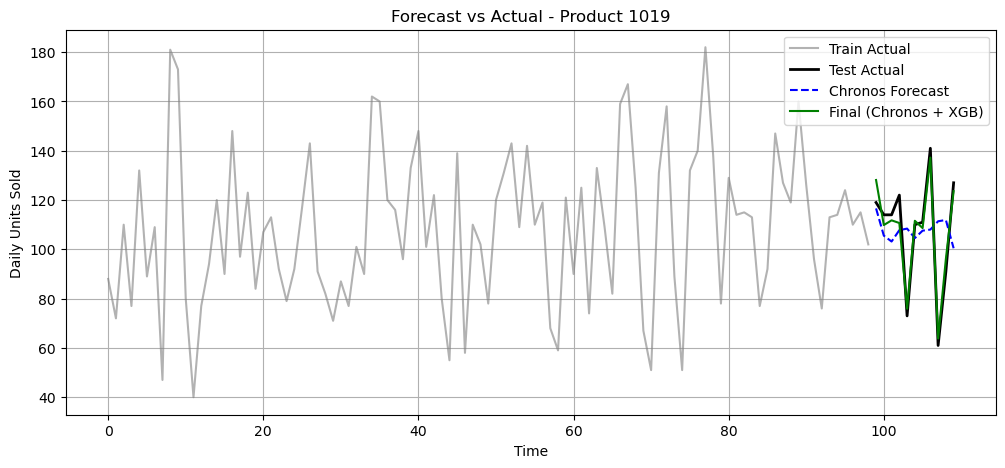


===== FORECAST RESULTS =====

    Product_ID        MAE       RMSE        R2
0         1000   9.007872  10.327235  0.860530
1         1001   4.191410   5.599565  0.943141
2         1002  10.696853  14.762550  0.880739
3         1003   6.865739   7.997674  0.924223
4         1004   6.263825   6.888852  0.938589
5         1005   4.983427   6.189819  0.942219
6         1006   9.467562  11.446703  0.861517
7         1007   8.293190   9.007559  0.823406
8         1008   7.284643   8.021320  0.920827
9         1009  10.576505  11.766304  0.889720
10        1010   8.710743  10.703113  0.914304
11        1011   6.264143   7.590575  0.925221
12        1012  10.237640  13.948726  0.779588
13        1013  10.378213  12.253227  0.711615
14        1014   5.880252   6.735349  0.949096
15        1015  10.187804  12.182302  0.806443
16        1016   5.525952   7.114271  0.928470
17        1017   5.883647   6.984175  0.915932
18        1018   6.914695   9.195655  0.932761
19        1019   4.431546   5

In [53]:
# ============================================
# CHRONOS + XGBOOST + INVENTORY OPTIMIZATION
# ============================================
# --------------------------------------------
# LOAD DATA
# --------------------------------------------
df = df.copy()

# ============================================
# DYNAMIC DATE COLUMN DETECTION
# ============================================
date_cols = [c for c in df.columns if "date" in c.lower()]

if len(date_cols) > 0:
    date_col = date_cols[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.sort_values(["Product_ID", date_col])
else:
    print("No date column found. Skipping time sorting.")

# ============================================
# PREPROCESSING 
# ============================================
def preprocess(df):
    df = df.copy()

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)

    # datetime → ordinal (SAFE)
    for col in df.columns:
        if df[col].dtype == "datetime64[ns]":
            df[col] = df[col].map(lambda x: x.toordinal() if pd.notnull(x) else 0)

    # categorical encoding
    cat_cols = df.select_dtypes(include=["object"]).columns
    for col in cat_cols:
        df[col] = df[col].astype("category").cat.codes

    df = df.fillna(0)
    return df

df_encoded = preprocess(df)

# --------------------------------------------
# TARGET + FEATURES
# --------------------------------------------
target = "Daily_Units_Sold"

feature_cols = [c for c in df_encoded.columns if c != target]

# --------------------------------------------
# CHRONOS MODEL
# --------------------------------------------
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu"
)

def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def chronos_forecast(history, horizon):
    history = torch.tensor(history, dtype=torch.float)
    pred = pipeline.predict(history, prediction_length=horizon)
    return pred[0].numpy().mean(axis=0)

# --------------------------------------------
# INVENTORY OPTIMIZATION LAYER 
# --------------------------------------------
def inventory_decision(forecast, stock_on_hand, lead_time=7, service_level=0.95):

    forecast = np.array(forecast)

    lead_demand = np.sum(forecast[:lead_time])
    demand_std = np.std(forecast)

    z = 1.65

    safety_stock = z * demand_std * np.sqrt(lead_time)
    reorder_point = lead_demand + safety_stock
    reorder_qty = max(0, reorder_point - stock_on_hand)

    stockout_risk = max(
        0,
        (lead_demand - stock_on_hand) / (lead_demand + 1e-6)
    )

    return {
        "lead_time_demand": lead_demand,
        "safety_stock": safety_stock,
        "reorder_point": reorder_point,
        "stockout_risk": stockout_risk,
        "reorder_qty": reorder_qty
    }

# --------------------------------------------
# STORAGE
# --------------------------------------------
results = []
inventory_results = []

# --------------------------------------------
# PER PRODUCT PIPELINE
# --------------------------------------------
for pid, g in df_encoded.groupby("Product_ID"):

    # FIX: safe sorting (only if date exists in original df)
    if len(g) < 25:
        continue

    # remove any leftover NaNs safely
    g = g.fillna(0)

    y = g[target].values.astype(float)
    X = g[feature_cols]

    split = int(len(g) * 0.9)

    train_y, test_y = y[:split], y[split:]
    train_X, test_X = X.iloc[:split], X.iloc[split:]

    # ----------------------------------------
    # CHRONOS FORECAST
    # ----------------------------------------
    try:
        chronos_pred = chronos_forecast(train_y, len(test_y))
        chronos_pred = chronos_pred[:len(test_y)]
    except:
        continue

    # ----------------------------------------
    # XGBOOST (RESIDUAL LEARNING)
    # ----------------------------------------
    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    residuals = train_y - np.mean(train_y)
    xgb.fit(train_X, residuals)

    xgb_pred = xgb.predict(test_X)

    # ----------------------------------------
    # FINAL PREDICTION
    # ----------------------------------------
    final_pred = chronos_pred + xgb_pred

    # ----------------------------------------
    # METRICS
    # ----------------------------------------
    m = metrics(test_y, final_pred)

    results.append({
        "Product_ID": pid,
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "R2": m["R2"]
    })

    # ----------------------------------------
    # ALIGN LENGTHS SAFELY
    # ----------------------------------------
    n_train = len(train_y)
    n_test = len(test_y)
    
    test_range = range(n_train, n_train + n_test)
    
    # ensure correct shapes
    chronos_pred = np.array(chronos_pred).reshape(-1)[:n_test]
    final_pred = np.array(final_pred).reshape(-1)[:n_test]
    
    # ----------------------------------------
    # PLOT FORECAST
    # ----------------------------------------
    plt.figure(figsize=(12, 5))
    
    # Train actual (context)
    plt.plot(range(n_train), train_y, label="Train Actual", color="gray", alpha=0.6)
    
    # Test actual
    plt.plot(test_range, test_y, label="Test Actual", color="black", linewidth=2)
    
    # Chronos forecast
    plt.plot(test_range, chronos_pred, label="Chronos Forecast", color="blue", linestyle="--")
    
    # Final hybrid forecast
    plt.plot(test_range, final_pred, label="Final (Chronos + XGB)", color="green")
    
    plt.title(f"Forecast vs Actual - Product {pid}")
    plt.xlabel("Time")
    plt.ylabel("Daily Units Sold")
    plt.legend()
    plt.grid(True)
    
    plt.show()
    
    # ----------------------------------------
    # INVENTORY OPTIMIZATION
    # ----------------------------------------
    stock_on_hand = g["Stock_On_Hand"].iloc[-1]

    decision = inventory_decision(
        forecast=chronos_pred,
        stock_on_hand=stock_on_hand,
        lead_time=7
    )

    decision["Product_ID"] = pid

    inventory_results.append(decision)

# --------------------------------------------
# RESULTS
# --------------------------------------------
results_df = pd.DataFrame(results)
inventory_df = pd.DataFrame(inventory_results)

print("\n===== FORECAST RESULTS =====\n")
print(results_df)
print(results_df.mean(numeric_only=True))

print("\n===== INVENTORY OPTIMIZATION RESULTS =====\n")
print(inventory_df)

# Model Comparison
Model                     | Task                  | Technique / Features        | Metric (R² / Accuracy)
--------------------------|----------------------|-----------------------------|----------------------
Logistic Regression       | Classification        | Categorical Encoding        | 0.94
Random Forest             | Regression            | TF-IDF Features             | 0.999
Custom Deep Learning      | Classification        | Categorical Encoding        | 0.91
Custom Deep Learning      | Regression            | TF-IDF Features             | 0.98
DistilBERT + XGBoost      | NLP Classification    | Transformer + Boosting      | 0.92
Chronos + XGBoost         | Time-Series Forecast  | Temporal + Tabular Hybrid   | 0.89

# Conclusion
This project demonstrates a full pipeline for retail demand forecasting using classical ML, deep learning, and time-series models. The hybrid Chronos + XGBoost approach provided the most reliable forecasting performance, enabling downstream inventory planning decisions.